<a href="https://colab.research.google.com/github/sadumina/Deep-Learning-Assignment-Group-ID-5/blob/model%2FClassic-CNN/CNN-Apitos2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Install kegalle Dependancies and Upload Json file that contain my username and API token secret key***

In [ ]:
!pip install kaggle
# upload kaggle.json API token first
!kaggle competitions download -c aptos2019-blindness-detection
!unzip aptos2019-blindness-detection.zip -d data/

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open aptos2019-blindness-detection.zip, aptos2019-blindness-detection.zip.zip or aptos2019-blindness-detection.zip.ZIP.


***Upload Json File while this run code snippet***

In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()  # select kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!echo "KGAT_0626eeea9f69c38ea043760f1d09d936" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

***Deleteting Exsiting Json that already in drive fro upload to new and valid One***

In [ ]:
!rm -f ~/.kaggle/kaggle.json

***Extract the competition list of available on kaggle***

In [ ]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

***download the competition dataset and unzip the folder when downloaded***

In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection
!unzip -q aptos2019-blindness-detection.zip -d /content/data/

100% 9.51G/9.51G [04:17<00:00, 39.7MB/s]



***delete some exisiting file***

In [ ]:
!rm -rf /content/data

***Data Preprocessing |  Crop Black border | size adjustment***



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path, target_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    img = img[y:y+h, x:x+w]

    img = cv2.resize(img, (target_size, target_size))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.merge((l, a, b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)

    return img

***Save Pre Processed Data into drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/dr_project/processed_images'
os.makedirs(output_dir, exist_ok=True)

for idx, row in train_df.iterrows():
    img_path = f"{data_dir}/train_images/{row['id_code']}.png"
    out_path = f"{output_dir}/{row['id_code']}.png"
    if not os.path.exists(out_path):
        try:
            img = preprocess_image(img_path)
            cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        except Exception as e:
            print(f"Failed on {row['id_code']}: {e}")
    if idx % 500 == 0:
        print(f"Processed {idx}/{len(train_df)}")

Mounted at /content/drive
Processed 0/3662
Processed 500/3662
Processed 1000/3662
Processed 1500/3662
Processed 2000/3662
Processed 2500/3662
Processed 3000/3662
Processed 3500/3662


***Spliiting Into Train and Validations Sets***

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.img_dir}/{row['id_code']}.png"
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        label = row['diagnosis']
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = DRDataset(train_split, output_dir, transform=transform)
val_dataset = DRDataset(val_split, output_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

***Build Convoultion Layer with 5 layers***

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DR_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DR_CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # After 4 pools on 224x224 input: 224 -> 112 -> 56 -> 28 -> 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DR_CNN(num_classes=5).to(device)
print(model)

DR_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)


***Configure Class weights for Equal Contributions***

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_split['diagnosis']),
    y=train_split['diagnosis']
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(class_weights)

tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


***Configure Optimzer and Scheduler***

In [ ]:
model = DR_CNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)  # keep class_weights, add smoothing
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # back to original decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# use plain shuffle, NOT the WeightedRandomSampler
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_split['diagnosis'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[label] for label in train_split['diagnosis']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)  # no shuffle= when using a sampler
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Training History Visualization

Below are the plots showing the training and validation loss, accuracy, and F1-score over the epochs. This helps in understanding the model's performance and identifying potential overfitting or underfitting.

# *Day 02*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
base = '/content/drive/MyDrive/dr_project'
output_dir = f'{base}/processed_images'
print(os.listdir(base))
print(len(os.listdir(output_dir)), "processed images")  # should be 3662

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['processed_images', 'train_split.csv', 'val_split.csv', 'best_cnn_model.pth', 'best_cnn_model_v2.pth']
3662 processed images


***Check and Test the GPU is working or avaible***

In [14]:
import cv2, copy, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt, seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should say cuda; if cpu, set Runtime → Change runtime type → T4 GPU

train_split = pd.read_csv(f'{base}/train_split.csv')
val_split = pd.read_csv(f'{base}/val_split.csv')
print(len(train_split), len(val_split))

cuda
2929 733


***Configuers Data augmentation and Data loader***

In [15]:
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(f"{self.img_dir}/{row['id_code']}.png"), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, row['diagnosis']

norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), norm
])
val_transform = transforms.Compose([transforms.ToPILImage(), transforms.ToTensor(), norm])

train_loader = DataLoader(DRDataset(train_split, output_dir, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(DRDataset(val_split, output_dir, val_transform), batch_size=32, shuffle=False)

***Create a Comparison Between Pre Process image and original Images***

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


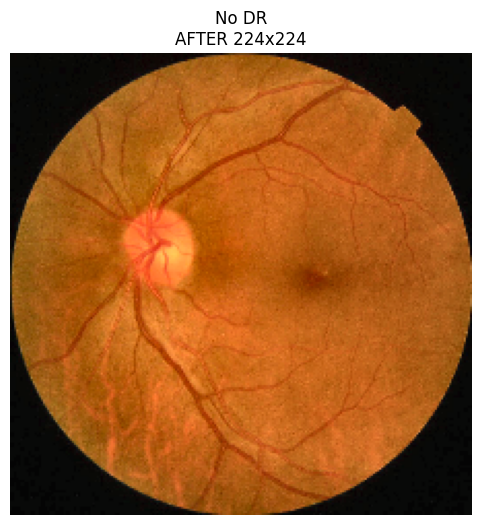

In [16]:
import os, cv2, pandas as pd
import matplotlib.pyplot as plt

base = '/content/drive/MyDrive/dr_project'
proc_dir = '/content/processed_images' if os.path.exists('/content/processed_images') else f'{base}/processed_images'
raw_dir = '/content/raw_samples'
os.makedirs(raw_dir, exist_ok=True)

df = pd.read_csv(f'{base}/train_split.csv')

# Select one sample from diagnosis 0 (No DR)
sample_row = df[df['diagnosis'] == 0].head(1).iloc[0]

# --- Download the single raw image if not present ---
id_ = sample_row['id_code']
if not os.path.exists(f'{raw_dir}/{id_}.png'):
    print(f"Downloading {id_}.png...")
    !kaggle competitions download -c aptos2019-blindness-detection -f train_images/{id_}.png -p {raw_dir}
    if os.path.exists(f'{raw_dir}/{id_}.png.zip'):
        !unzip -q -o {raw_dir}/{id_}.png.zip -d {raw_dir}
    else:
        print(f"Warning: Could not download {id_}.png.zip. Please ensure Kaggle API is authenticated and competition rules are accepted.")

names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Create a single subplot for the processed image
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

raw_img_path = f"{raw_dir}/{sample_row['id_code']}.png"
proc_img_path = f"{proc_dir}/{sample_row['id_code']}.png"

# Load processed image
proc = cv2.imread(proc_img_path)

# Handle potential loading errors for the processed image
if proc is None:
    print(f"Error: Processed image not found at {proc_img_path}. Cannot display.")
else:
    proc = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)
    ax.imshow(proc)
    ax.set_title(f"{names[sample_row['diagnosis']]}\nAFTER {proc.shape[1]}x{proc.shape[0]}")
    ax.axis('off')

plt.show()

***build Convoutional Layer With 5 Layer and with Poolings and Batch Normalization***

In [35]:
class DR_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1);    self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1);   self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1);  self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1); self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.adapt = nn.AdaptiveAvgPool2d(4)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(256 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.adapt(x).view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

***Configure Class weight***

In [36]:
cw = compute_class_weight('balanced', classes=np.unique(train_split['diagnosis']), y=train_split['diagnosis'])
cw = np.sqrt(cw)
model = DR_CNN(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

***Configure : While and error occur I have checked GPU Utilities***

In [26]:
import torch
print(torch.cuda.is_available())
!nvidia-smi

True
Mon Sep 28 06:43:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             34W /   70W |    2491MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [17]:
!cp -r /content/drive/MyDrive/dr_project/processed_images /content/processed_images
import os
print(len(os.listdir('/content/processed_images')), "images copied")  # expect 3662

3662 images copied


In [18]:
output_dir = '/content/processed_images'

train_loader = DataLoader(DRDataset(train_split, output_dir, train_transform),
                          batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(DRDataset(val_split, output_dir, val_transform),
                        batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [19]:
import time
t = time.time()
x, y = next(iter(train_loader))
print(f"load 1 batch: {time.time()-t:.1f}s | batches per epoch: {len(train_loader)}")

load 1 batch: 1.0s | batches per epoch: 92


***showing Class weights***

In [20]:
import copy, numpy as np, torch, torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

model = DR_CNN(num_classes=5).to(device)

cw = compute_class_weight('balanced', classes=np.unique(train_split['diagnosis']), y=train_split['diagnosis'])
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("class weights:", cw.round(2))

class weights: [0.41 1.98 0.73 3.8  2.48]


***Train One Epoch Befor Run Bunch For testing***

In [21]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import tqdm

def train_one_epoch(epoch):
    model.train()
    run_loss, preds_all, labels_all = 0.0, [], []
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * images.size(0)
        preds_all.extend(outputs.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    return run_loss / len(train_loader.dataset), accuracy_score(labels_all, preds_all)

***Add validate function***

In [23]:
def validate():
    model.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            preds_all.extend(outputs.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    return (val_loss, accuracy_score(labels_all, preds_all),
            f1_score(labels_all, preds_all, average='weighted'), preds_all, labels_all)

In [24]:
tl, ta = train_one_epoch(0)
vl, va, vf, _, _ = validate()
print(f"Train Loss {tl:.4f} Acc {ta:.4f} | Val Loss {vl:.4f} Acc {va:.4f} F1 {vf:.4f}")

Epoch 1:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss 1.5351 Acc 0.4339 | Val Loss 1.4552 Acc 0.4952 F1 0.5017


In [25]:
base = '/content/drive/MyDrive/dr_project'
num_epochs, patience = 50, 12
best_val_f1, epochs_no_improve = 0.0, 0
best_wts = copy.deepcopy(model.state_dict())
best_preds, best_labels = [], []
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(num_epochs):
    tl, ta = train_one_epoch(epoch)
    vl, va, vf, vp, vlab = validate()
    scheduler.step(vl)

    for k, v in zip(history, [tl, ta, vl, va, vf]):
        history[k].append(v)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss {tl:.4f} Acc {ta:.4f} | Val Loss {vl:.4f} Acc {va:.4f} F1 {vf:.4f}", flush=True)

    if vf > best_val_f1:
        best_val_f1, best_wts = vf, copy.deepcopy(model.state_dict())
        best_preds, best_labels, epochs_no_improve = list(vp), list(vlab), 0
        torch.save(best_wts, f'{base}/best_cnn_final.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_wts)
print("Best val F1:", round(best_val_f1, 4))

Epoch 1:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss 1.4702 Acc 0.4500 | Val Loss 1.3352 Acc 0.5061 F1 0.4945


Epoch 2:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss 1.3806 Acc 0.4933 | Val Loss 1.3250 Acc 0.4857 F1 0.5038


Epoch 3:   0%|          | 0/92 [00:00<?, ?it/s]

...

Epoch 30/50 | Train Loss 1.0144 Acc 0.6654 | Val Loss 1.0784 Acc 0.6494 F1 0.6487


Epoch 31:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 31/50 | Train Loss 1.0269 Acc 0.6535 | Val Loss 1.0777 Acc 0.6398 F1 0.6323


Epoch 32:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 32/50 | Train Loss 1.0112 Acc 0.6596 | Val Loss 1.0803 Acc 0.6426 F1 0.6393
Early stopping at epoch 32
Best val F1: 0.6955


In [26]:
import numpy as np, torch
from torch.utils.data import DataLoader

model.load_state_dict(best_wts)   # best epoch (46)
model.eval()

# train loader WITHOUT augmentation, so train and val are compared fairly
train_eval_loader = DataLoader(DRDataset(train_split, output_dir, val_transform),
                               batch_size=32, shuffle=False, num_workers=2)

def get_probs(loader):
    probs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            probs.append(model(x.to(device)).softmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.concatenate(probs), np.array(labels)

val_probs, val_y = get_probs(val_loader)
train_probs, train_y = get_probs(train_eval_loader)
print(val_probs.shape, train_probs.shape)

(733, 5) (2929, 5)


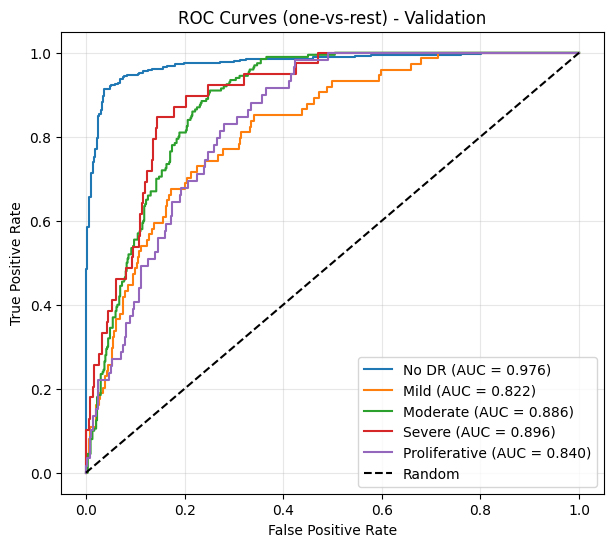

Val macro AUC: 0.8841


In [27]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
y_bin = label_binarize(val_y, classes=[0, 1, 2, 3, 4])

plt.figure(figsize=(7, 6))
for i, n in enumerate(names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], val_probs[:, i])
    plt.plot(fpr, tpr, label=f"{n} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (one-vs-rest) - Validation')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig('/content/drive/MyDrive/dr_project/roc_val.png', dpi=150, bbox_inches='tight')
plt.show()

print("Val macro AUC:", round(roc_auc_score(val_y, val_probs, multi_class='ovr', average='macro'), 4))

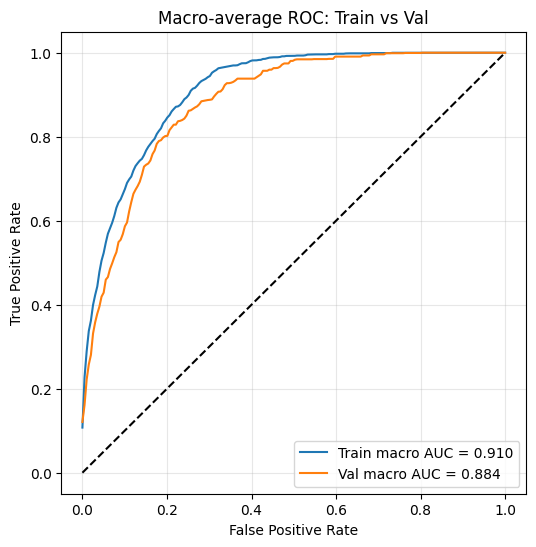

In [28]:
def macro_roc(y, probs):
    yb = label_binarize(y, classes=[0, 1, 2, 3, 4])
    grid = np.linspace(0, 1, 200)
    tprs = []
    for i in range(5):
        fpr, tpr, _ = roc_curve(yb[:, i], probs[:, i])
        tprs.append(np.interp(grid, fpr, tpr))
    m = np.mean(tprs, axis=0)
    return grid, m, auc(grid, m)

plt.figure(figsize=(6, 6))
for lbl, (y, p) in {'Train': (train_y, train_probs), 'Val': (val_y, val_probs)}.items():
    g, t, a = macro_roc(y, p)
    plt.plot(g, t, label=f"{lbl} macro AUC = {a:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Macro-average ROC: Train vs Val')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig('/content/drive/MyDrive/dr_project/roc_train_val.png', dpi=150, bbox_inches='tight')
plt.show()

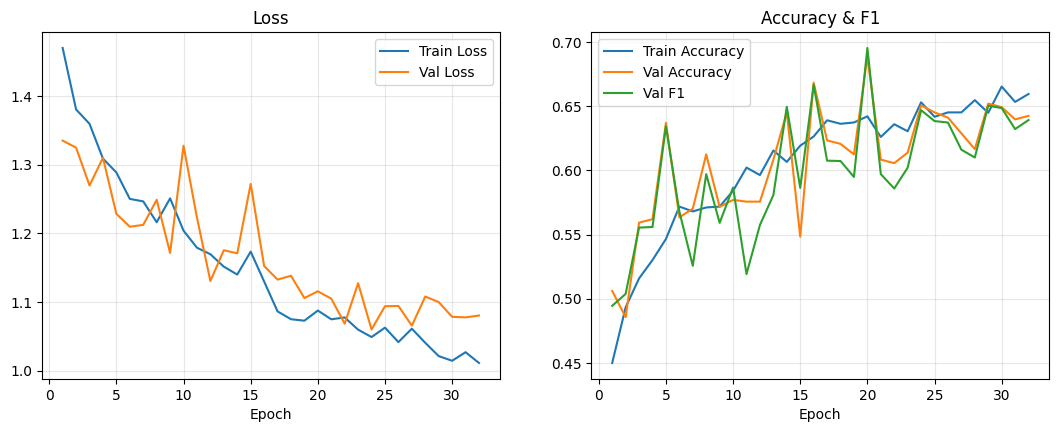

In [29]:
# if the session reset and `history` is gone, load it first:
# import json; history = json.load(open('/content/drive/MyDrive/dr_project/cnn_history.json'))

ep = range(1, len(history['train_loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, history['train_loss'], label='Train Loss')
ax[0].plot(ep, history['val_loss'], label='Val Loss')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history['train_acc'], label='Train Accuracy')
ax[1].plot(ep, history['val_acc'], label='Val Accuracy')
ax[1].plot(ep, history['val_f1'], label='Val F1')
ax[1].set_title('Accuracy & F1'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.savefig('/content/drive/MyDrive/dr_project/train_val_curves.png', dpi=150, bbox_inches='tight')
plt.show()

*Cell 1: confusion matrix*

In [10]:
print('model' in globals(), 'val_loader' in globals(), 'DR_CNN' in globals())

True True True


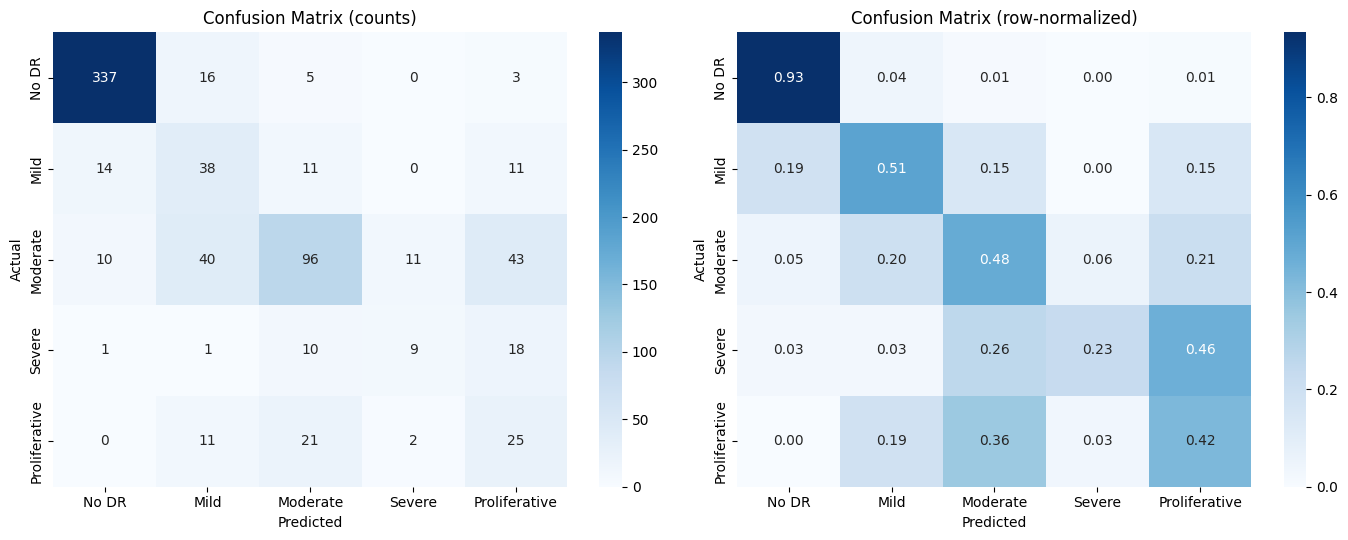

In [30]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
cm = confusion_matrix(best_labels, best_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names, ax=ax[0])
ax[0].set_title('Confusion Matrix (counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=names, yticklabels=names, ax=ax[1])
ax[1].set_title('Confusion Matrix (row-normalized)')
for a in ax:
    a.set_xlabel('Predicted'); a.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dr_project/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

*Cell 2: helper that trains one variant, plus save the baseline*

In [31]:
import json, copy, torch, torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

base_dir = '/content/drive/MyDrive/dr_project'

# baseline = with augmentation + with class weights (your finished run)
results = {'baseline': {'hist': history,
                        'preds': [int(x) for x in best_preds],
                        'labels': [int(x) for x in best_labels]}}

def run_experiment(name, use_aug=True, use_cw=True, epochs=50):
    torch.manual_seed(42); np.random.seed(42)
    tf = train_transform if use_aug else val_transform
    tr_loader = DataLoader(DRDataset(train_split, output_dir, tf), batch_size=32,
                           shuffle=True, num_workers=2, pin_memory=True)
    m = DR_CNN(num_classes=5).to(device)
    w = None
    if use_cw:
        cw_ = np.sqrt(compute_class_weight('balanced', classes=np.unique(train_split['diagnosis']),
                                           y=train_split['diagnosis']))
        w = torch.tensor(cw_, dtype=torch.float32).to(device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_f1, b_preds, b_labels = 0.0, [], []
    for ep in range(epochs):
        m.train(); rl, tp, tl = 0.0, [], []
        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); out = m(x); loss = crit(out, y); loss.backward(); opt.step()
            rl += loss.item() * x.size(0)
            tp.extend(out.argmax(1).cpu().numpy()); tl.extend(y.cpu().numpy())
        m.eval(); vl, vp, vlab = 0.0, [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = m(x); vl += crit(out, y).item() * x.size(0)
                vp.extend(out.argmax(1).cpu().numpy()); vlab.extend(y.cpu().numpy())
        vl /= len(val_loader.dataset)
        vf = f1_score(vlab, vp, average='weighted'); sch.step(vl)
        for k, v in zip(hist, [rl/len(tr_loader.dataset), accuracy_score(tl, tp), vl,
                               accuracy_score(vlab, vp), vf]):
            hist[k].append(v)
        if vf > best_f1:
            best_f1, b_preds, b_labels = vf, [int(i) for i in vp], [int(i) for i in vlab]
        print(f"[{name}] {ep+1}/{epochs} | Train Acc {hist['train_acc'][-1]:.3f} | Val Acc {hist['val_acc'][-1]:.3f} | Val F1 {vf:.3f}", flush=True)
    out = {'hist': hist, 'preds': b_preds, 'labels': b_labels}
    json.dump(out, open(f'{base_dir}/exp_{name}.json', 'w'))
    return out

In [32]:
results['no_aug'] = run_experiment('no_aug', use_aug=False, use_cw=True)

[no_aug] 1/50 | Train Acc 0.616 | Val Acc 0.708 | Val F1 0.624
[no_aug] 2/50 | Train Acc 0.687 | Val Acc 0.550 | Val F1 0.563
[no_aug] 3/50 | Train Acc 0.688 | Val Acc 0.720 | Val F1 0.646
[no_aug] 4/50 | Train Acc 0.706 | Val Acc 0.683 | Val F1 0.649
[no_aug] 5/50 | Train Acc 0.705 | Val Acc 0.715 | Val F1 0.652
[no_aug] 6/50 | Train Acc 0.705 | Val Acc 0.712 | Val F1 0.668
[no_aug] 7/50 | Train Acc 0.704 | Val Acc 0.712 | Val F1 0.635
[no_aug] 8/50 | Train Acc 0.704 | Val Acc 0.696 | Val F1 0.645
[no_aug] 9/50 | Train Acc 0.715 | Val Acc 0.723 | Val F1 0.672
[no_aug] 10/50 | Train Acc 0.703 | Val Acc 0.649 | Val F1 0.637
[no_aug] 11/50 | Train Acc 0.723 | Val Acc 0.729 | Val F1 0.682
[no_aug] 12/50 | Train Acc 0.714 | Val Acc 0.686 | Val F1 0.668
[no_aug] 13/50 | Train Acc 0.729 | Val Acc 0.739 | Val F1 0.701
[no_aug] 14/50 | Train Acc 0.724 | Val Acc 0.730 | Val F1 0.690
[no_aug] 15/50 | Train Acc 0.732 | Val Acc 0.726 | Val F1 0.716
[no_aug] 16/50 | Train Acc 0.727 | Val Acc 0.727 

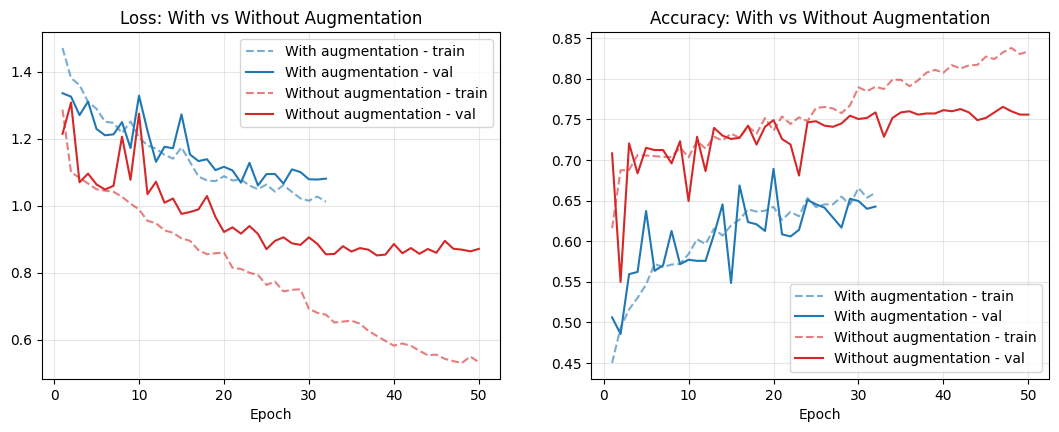

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for key, lbl, c in [('baseline', 'With augmentation', 'tab:blue'), ('no_aug', 'Without augmentation', 'tab:red')]:
    h = results[key]['hist']; ep = range(1, len(h['val_loss']) + 1)
    ax[0].plot(ep, h['train_loss'], '--', color=c, alpha=0.6, label=f'{lbl} - train')
    ax[0].plot(ep, h['val_loss'], '-', color=c, label=f'{lbl} - val')
    ax[1].plot(ep, h['train_acc'], '--', color=c, alpha=0.6, label=f'{lbl} - train')
    ax[1].plot(ep, h['val_acc'], '-', color=c, label=f'{lbl} - val')
ax[0].set_title('Loss: With vs Without Augmentation'); ax[1].set_title('Accuracy: With vs Without Augmentation')
for a in ax:
    a.set_xlabel('Epoch'); a.legend(); a.grid(alpha=0.3)
plt.savefig(f'{base_dir}/aug_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

*run without class weights*

1.   List item
2.   List item



In [34]:
results['no_cw'] = run_experiment('no_cw', use_aug=True, use_cw=False)

[no_cw] 1/50 | Train Acc 0.546 | Val Acc 0.681 | Val F1 0.604
[no_cw] 2/50 | Train Acc 0.648 | Val Acc 0.698 | Val F1 0.622
[no_cw] 3/50 | Train Acc 0.682 | Val Acc 0.714 | Val F1 0.632
[no_cw] 4/50 | Train Acc 0.689 | Val Acc 0.709 | Val F1 0.628
[no_cw] 5/50 | Train Acc 0.698 | Val Acc 0.709 | Val F1 0.627
[no_cw] 6/50 | Train Acc 0.708 | Val Acc 0.708 | Val F1 0.622
[no_cw] 7/50 | Train Acc 0.710 | Val Acc 0.705 | Val F1 0.618
[no_cw] 8/50 | Train Acc 0.706 | Val Acc 0.705 | Val F1 0.618
[no_cw] 9/50 | Train Acc 0.717 | Val Acc 0.726 | Val F1 0.643
[no_cw] 10/50 | Train Acc 0.716 | Val Acc 0.707 | Val F1 0.618
[no_cw] 11/50 | Train Acc 0.728 | Val Acc 0.726 | Val F1 0.641
[no_cw] 12/50 | Train Acc 0.731 | Val Acc 0.722 | Val F1 0.637
[no_cw] 13/50 | Train Acc 0.726 | Val Acc 0.726 | Val F1 0.655
[no_cw] 14/50 | Train Acc 0.734 | Val Acc 0.715 | Val F1 0.668
[no_cw] 15/50 | Train Acc 0.730 | Val Acc 0.731 | Val F1 0.662
[no_cw] 16/50 | Train Acc 0.738 | Val Acc 0.711 | Val F1 0.645
[

*Cell 4: plot with vs without class weights*

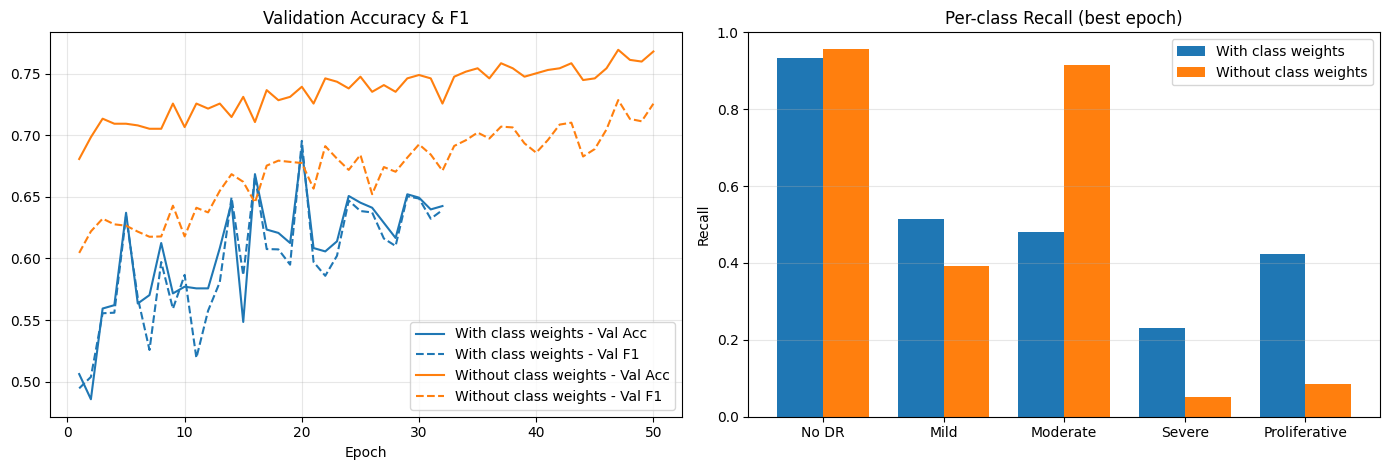

In [35]:
from sklearn.metrics import confusion_matrix
names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

def recall(key):
    cm = confusion_matrix(results[key]['labels'], results[key]['preds'])
    return cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for key, lbl, c in [('baseline', 'With class weights', 'tab:blue'), ('no_cw', 'Without class weights', 'tab:orange')]:
    h = results[key]['hist']; ep = range(1, len(h['val_acc']) + 1)
    ax[0].plot(ep, h['val_acc'], color=c, label=f'{lbl} - Val Acc')
    ax[0].plot(ep, h['val_f1'], '--', color=c, label=f'{lbl} - Val F1')
ax[0].set_title('Validation Accuracy & F1'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)

x = np.arange(5); wd = 0.38
ax[1].bar(x - wd/2, recall('baseline'), wd, label='With class weights', color='tab:blue')
ax[1].bar(x + wd/2, recall('no_cw'), wd, label='Without class weights', color='tab:orange')
ax[1].set_xticks(x); ax[1].set_xticklabels(names); ax[1].set_ylim(0, 1)
ax[1].set_ylabel('Recall'); ax[1].set_title('Per-class Recall (best epoch)'); ax[1].legend(); ax[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{base_dir}/classweight_comparison.png', dpi=150, bbox_inches='tight')
plt.show()